In [11]:
# Import libraries required for data manipulation, analysis, and visualization.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for consistent plots.
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns when viewing DataFrames.
pd.set_option("display.max_columns", None)

## Demand feature EDA
Demand here is not a standalone raw feature. It is derived by normalizing the three component features and then averaging them. The EDA should therefore focus on how those components behave individually and how they combine into the final Demand score.

In [29]:
# Load demand feature dataset
df = pd.read_csv("../data/processed/sub_groups/demand_features.csv")

# Component features used to form the Demand score
component_cols = ["Anchor_Destinations", "Daytime_Population", "Commercial_Vitality"]
score_col = "Demand"

# Preview data
print(df[["search_area"] + component_cols + [score_col]].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[["search_area"] + component_cols + [score_col]].isnull().sum())


  search_area  Anchor_Destinations  Daytime_Population  Commercial_Vitality  \
0   Baneshwor               0.1121              0.4828               0.3035   
1   Baneshwor               0.1265              0.5931               0.4827   
2   Baneshwor               0.1779              0.6513               0.5083   
3   Baneshwor               0.1264              0.2961               0.2731   
4   Baneshwor               0.1803              0.6303               0.4946   

   Demand  
0  0.2995  
1  0.4008  
2  0.4458  
3  0.2319  
4  0.4351  
Dataset shape: (1472, 9)
Missing values:
 search_area            0
Anchor_Destinations    0
Daytime_Population     0
Commercial_Vitality    0
Demand                 0
dtype: int64


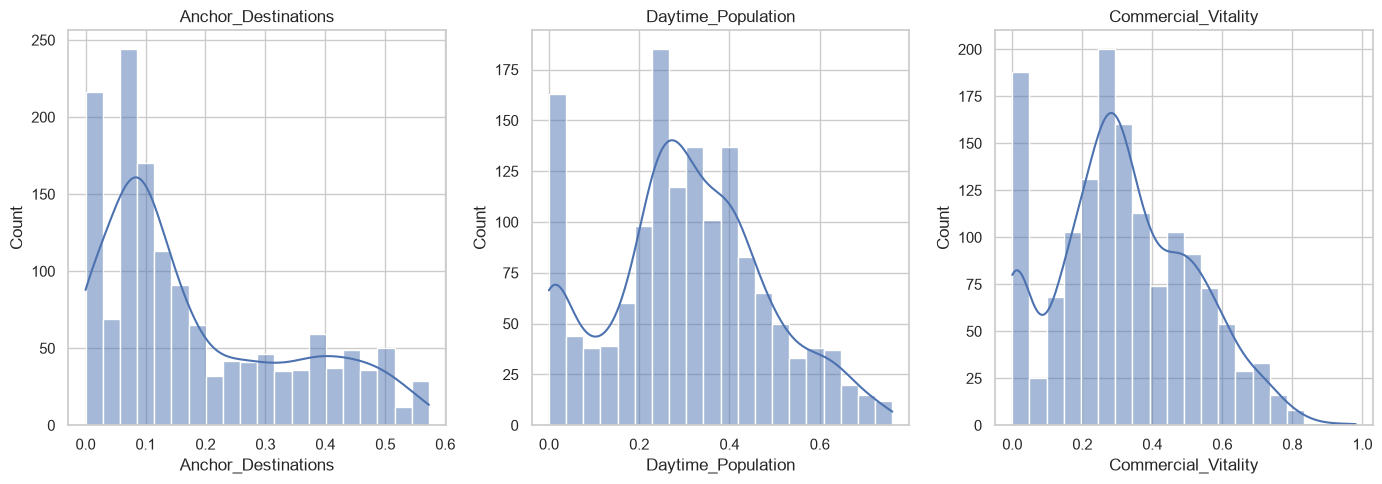

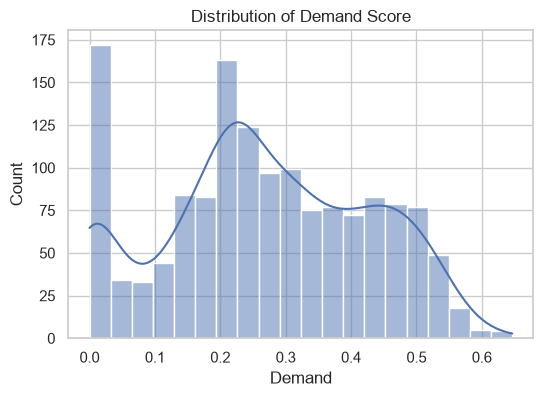

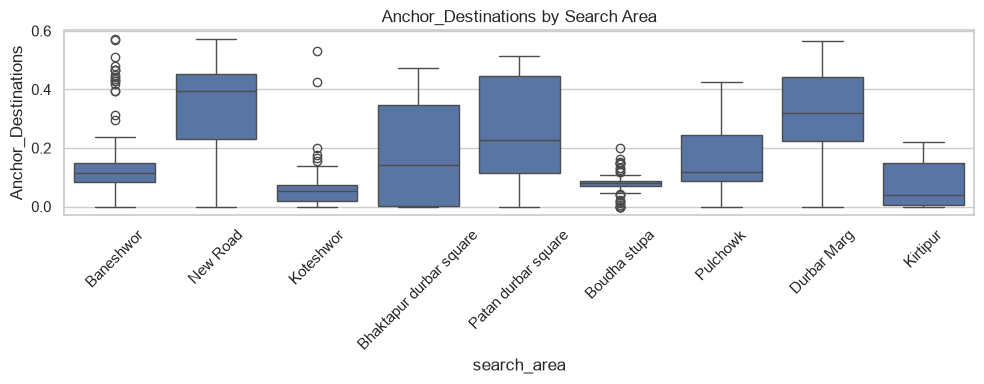

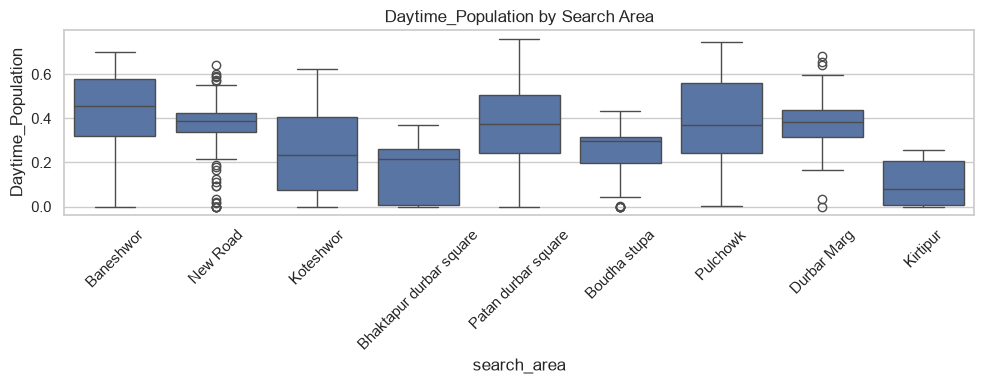

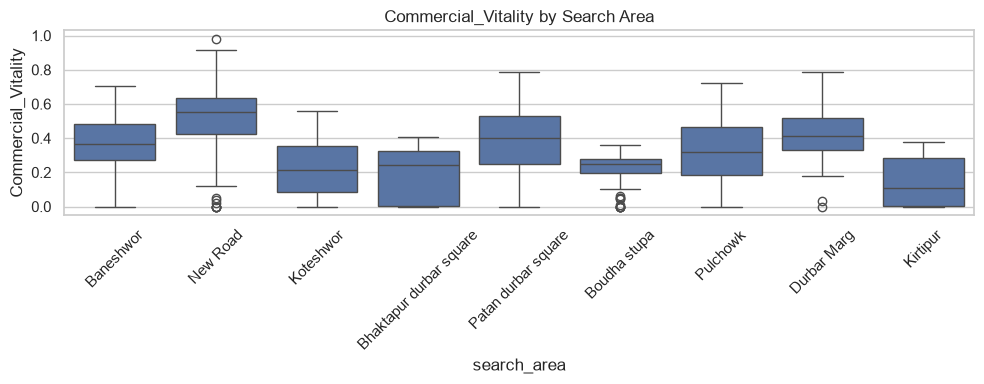

In [30]:
# Summary statistics of the three components and the final score
summary = df[["Anchor_Destinations", "Daytime_Population", "Commercial_Vitality", "Demand"]].describe().T
summary

# Histograms for the three component features
plt.figure(figsize=(14, 5))
for i, col in enumerate(component_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

# Distribution of the final Demand score
plt.figure(figsize=(6, 4))
sns.histplot(df[score_col], kde=True, bins=20)
plt.title('Distribution of Demand Score')
plt.show()

# Compare the component distributions by search area
for col in component_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='search_area', y=col)
    plt.title(f'{col} by Search Area')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


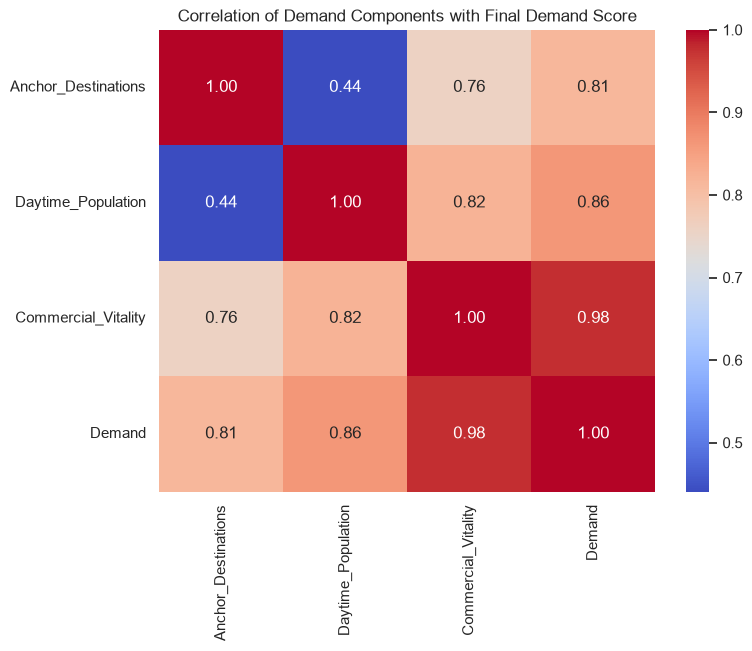

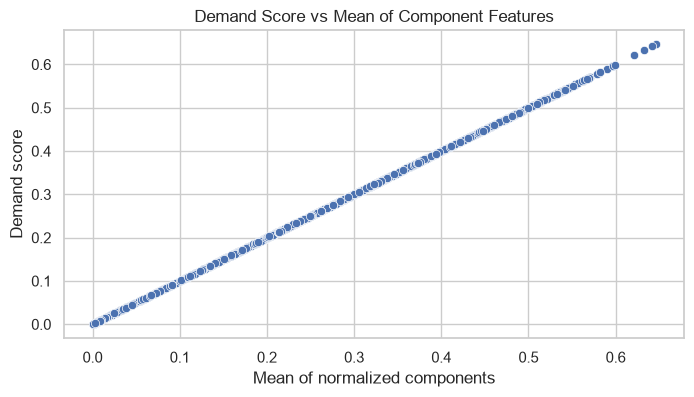

,Anchor_Destinations,Daytime_Population,Commercial_Vitality,Demand
search_area,,,,
New Road,0.342717,0.368883,0.518210,0.409937
Durbar Marg,0.322003,0.379288,0.421956,0.374417
Patan durbar square,0.247853,0.380688,0.392853,0.340466
Baneshwor,0.131426,0.425908,0.350678,0.302672
Pulchowk,0.158153,0.395934,0.328838,0.294306
Boudha stupa,0.078689,0.256560,0.228440,0.187899
Bhaktapur durbar square,0.178736,0.167328,0.197295,0.181121
Koteshwor,0.061372,0.242031,0.219870,0.174423
Kirtipur,0.077899,0.103660,0.136630,0.106062


In [33]:
# Correlation between the three component features and the derived Demand score
corr = df[component_cols + [score_col]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Demand Components with Final Demand Score')
plt.show()

# Check whether the score is close to the average of the components
# (since the derived score is expected to be an average-like summary)
df['component_mean'] = df[component_cols].mean(axis=1)
df[['component_mean', score_col]].head()

# Compare the derived score with the simple average of components
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='component_mean', y=score_col)
plt.title('Demand Score vs Mean of Component Features')
plt.xlabel('Mean of normalized components')
plt.ylabel('Demand score')
plt.show()

# Area-level summary of the final score and component averages
area_summary = df.groupby('search_area').agg({
    'Anchor_Destinations': 'mean',
    'Daytime_Population': 'mean',
    'Commercial_Vitality': 'mean',
    'Demand': 'mean'
}).sort_values('Demand', ascending=False)
area_summary


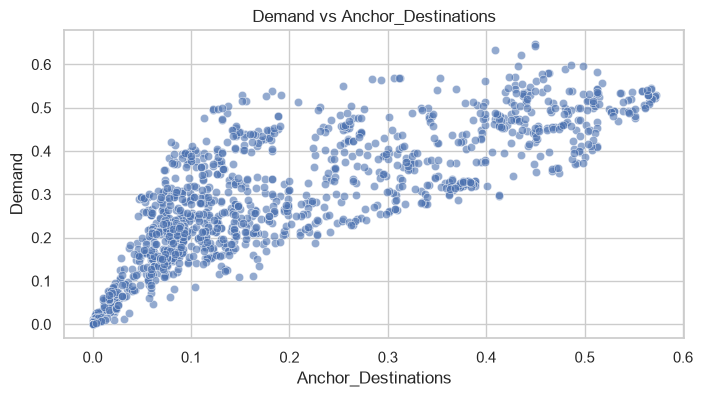

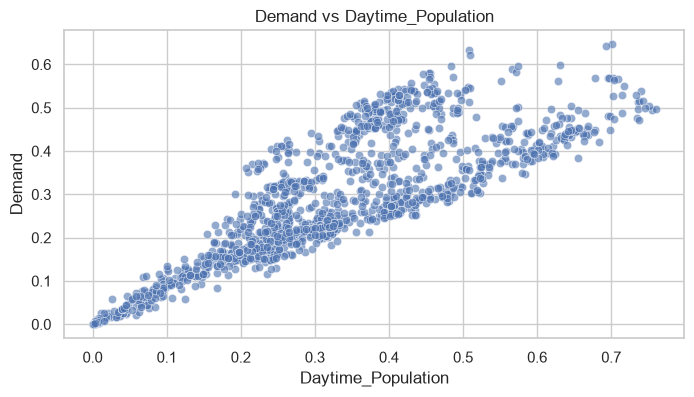

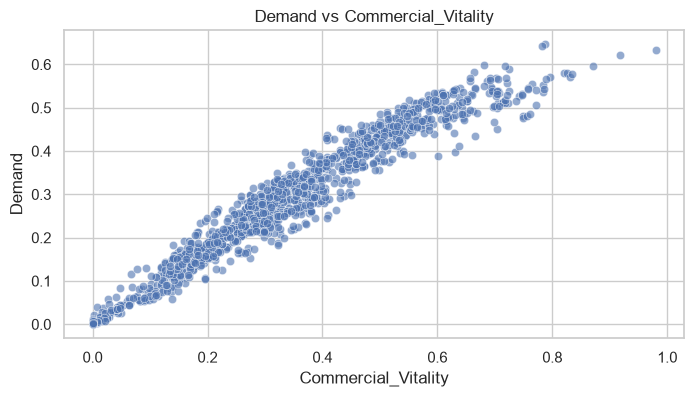

Interpretation: if one component dominates the scatter plots and correlations, it may be driving the Demand score more than the others.


In [32]:
# Inspect whether one component dominates the Demand score
for col in component_cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=df, x=df[col], y=df[score_col], alpha=0.6)
    plt.title(f'{score_col} vs {col}')
    plt.xlabel(col)
    plt.ylabel(score_col)
    plt.show()

# Quick interpretation note
print("Interpretation: if one component dominates the scatter plots and correlations, it may be driving the Demand score more than the others.")


## House density feature EDA
This subgroup contains a single density-based feature, building_count_500m, which reflects the local building intensity around each restaurant location.

In [37]:
# Load house density feature dataset
df = pd.read_csv("../data/processed/sub_groups/house_density_features.csv")

# Keep the relevant columns for EDA
feature_col = "building_count_500m"

# Preview data
print(df[["search_area", feature_col]].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[["search_area", feature_col]].isnull().sum())


  search_area  building_count_500m
0   Baneshwor                 2695
1   Baneshwor                 2489
2   Baneshwor                 2413
3   Baneshwor                 3176
4   Baneshwor                 2437
Dataset shape: (1472, 6)
Missing values:
 search_area            0
building_count_500m    0
dtype: int64


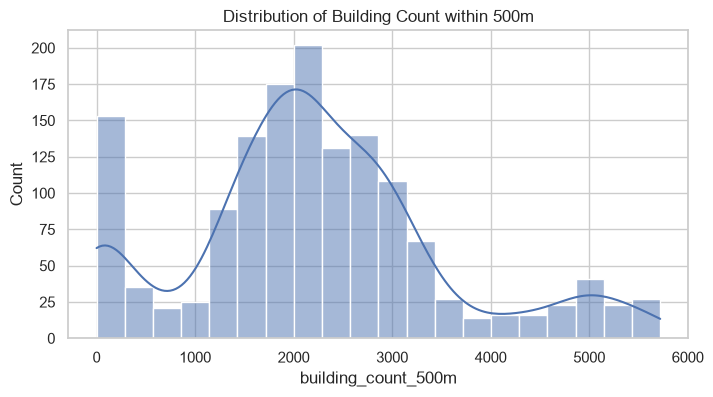

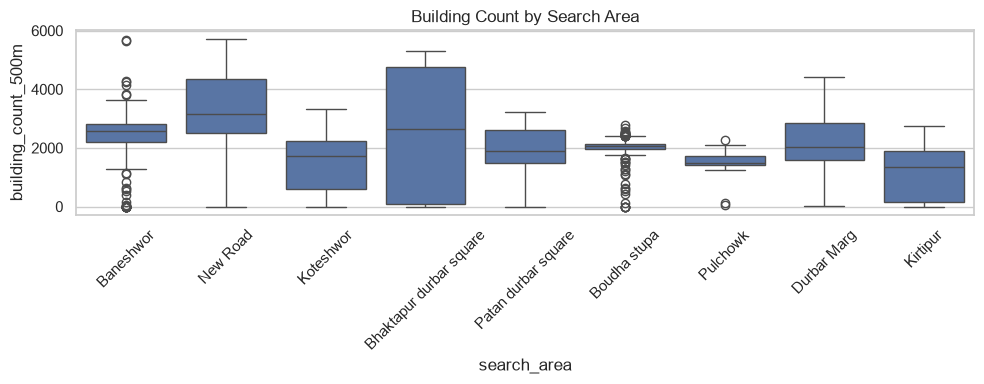

search_area
New Road                   3324.405530
Bhaktapur durbar square    2528.944954
Baneshwor                  2408.293103
Durbar Marg                2168.571429
Boudha stupa               1965.312796
Patan durbar square        1947.092593
Pulchowk                   1528.468085
Koteshwor                  1507.138614
Kirtipur                   1146.552000
Name: building_count_500m, dtype: float64

In [38]:
# Summary statistics for house density
summary = df[[feature_col]].describe().T
summary

# Histogram for house density
plt.figure(figsize=(8, 4))
sns.histplot(df[feature_col], kde=True, bins=20)
plt.title('Distribution of Building Count within 500m')
plt.show()

# Boxplot by search area
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='search_area', y=feature_col)
plt.title('Building Count by Search Area')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Area-level average building count
area_summary = df.groupby('search_area')[feature_col].mean().sort_values(ascending=False)
area_summary


## Accessibility feature EDA
This section analyzes the raw accessibility features: bus stop count, parking space count, intersection count, and distance to main road.

In [40]:
# Load raw accessibility feature dataset
df = pd.read_csv("../data/processed/sub_groups/accessibility_features.csv")

# Relevant columns for accessibility feature EDA
feature_cols = ["bus_stop_count_500m", "parking_space_count_500m", "intersection_count_500m", "dist_to_main_road_m"]

# Preview data
print(df[["search_area"] + feature_cols].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[["search_area"] + feature_cols].isnull().sum())

# Summary statistics
summary = df[feature_cols].describe().T
summary


  search_area  bus_stop_count_500m  parking_space_count_500m  \
0   Baneshwor                    1                         5   
1   Baneshwor                    4                         6   
2   Baneshwor                    6                         9   
3   Baneshwor                    0                         4   
4   Baneshwor                    6                        10   

   intersection_count_500m  dist_to_main_road_m  
0                      138                 71.4  
1                      128                 27.6  
2                      129                 53.0  
3                      364                 14.7  
4                      136                 20.9  
Dataset shape: (1472, 9)
Missing values:
 search_area                 0
bus_stop_count_500m         0
parking_space_count_500m    0
intersection_count_500m     0
dist_to_main_road_m         0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
bus_stop_count_500m,1472.0,2.120924,2.243879,0.0,0.000,1.0,3.000,11.0
parking_space_count_500m,1472.0,5.622283,5.443361,0.0,1.000,4.0,10.000,23.0
intersection_count_500m,1472.0,106.873641,53.718457,0.0,88.750,110.0,133.000,376.0
dist_to_main_road_m,1472.0,330.426970,612.184400,0.3,21.125,131.9,298.725,7523.4


  search_area  bus_stop_count_500m  parking_space_count_500m  \
0   Baneshwor                    1                         5   
1   Baneshwor                    4                         6   
2   Baneshwor                    6                         9   
3   Baneshwor                    0                         4   
4   Baneshwor                    6                        10   

   intersection_count_500m  dist_to_main_road_m  
0                      138                 71.4  
1                      128                 27.6  
2                      129                 53.0  
3                      364                 14.7  
4                      136                 20.9  
Dataset shape: (1472, 9)
Missing values:
 search_area                 0
bus_stop_count_500m         0
parking_space_count_500m    0
intersection_count_500m     0
dist_to_main_road_m         0
dtype: int64


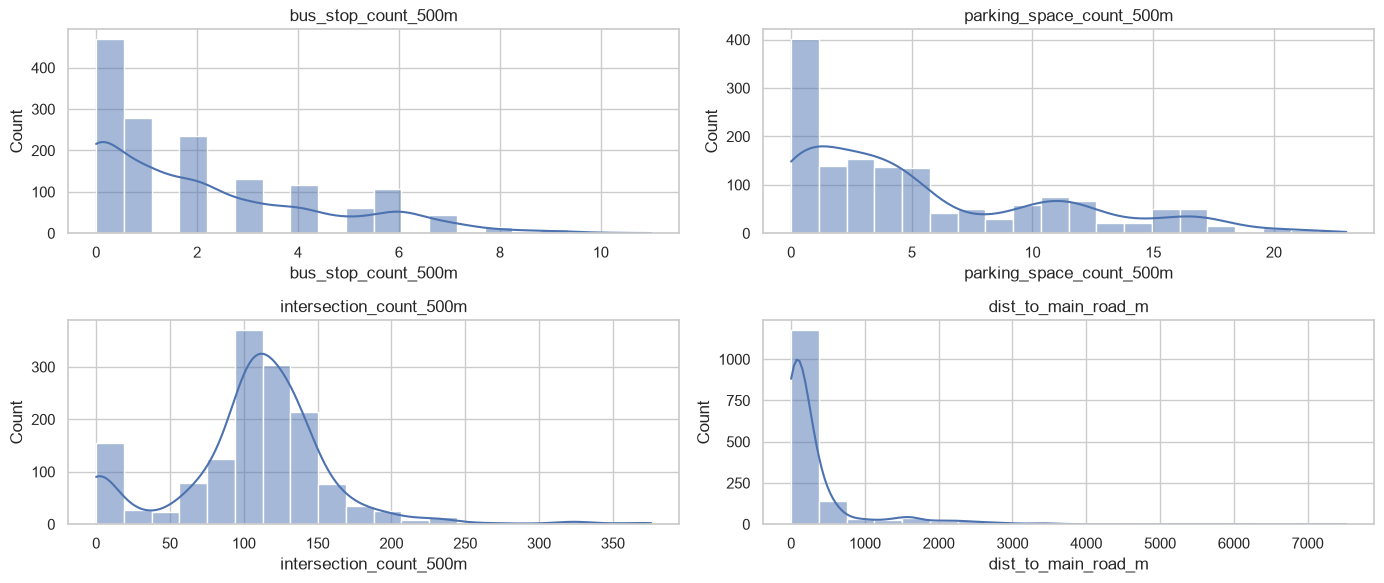

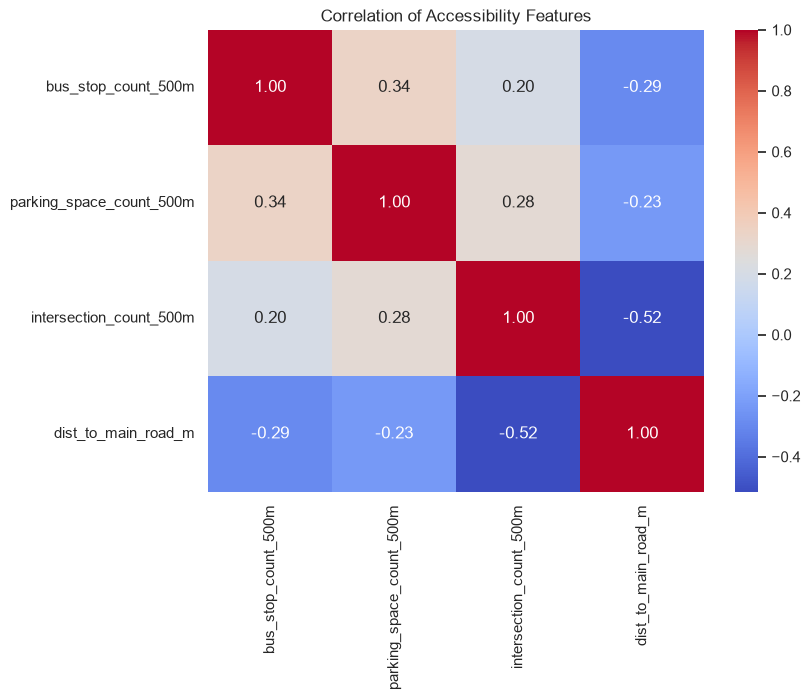

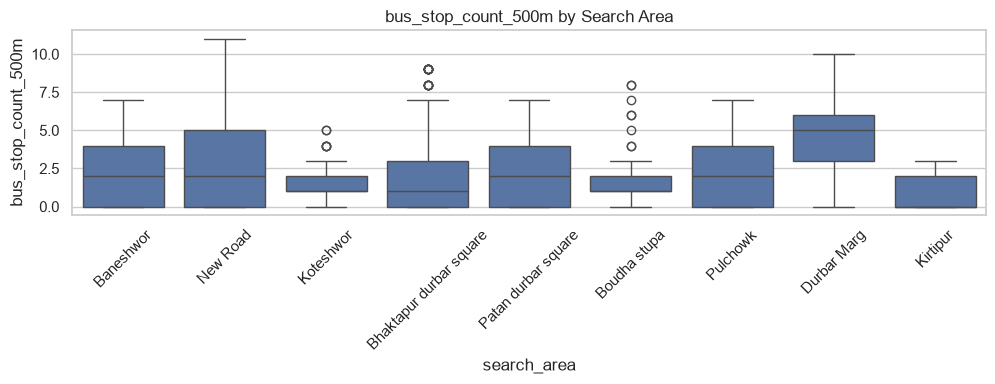

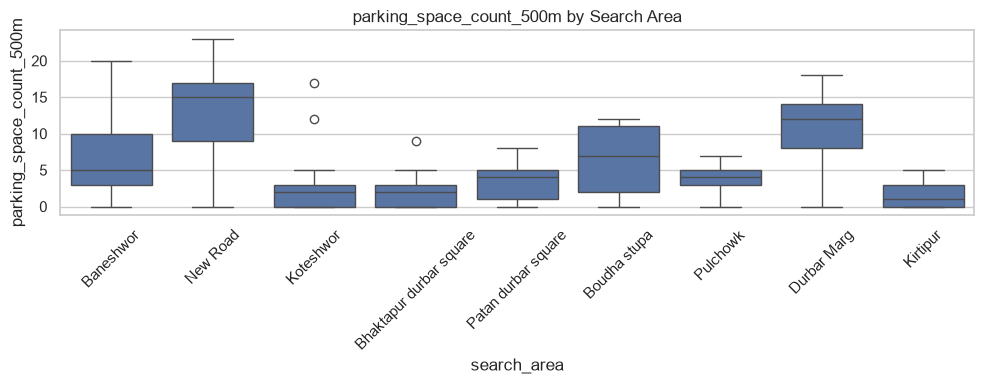

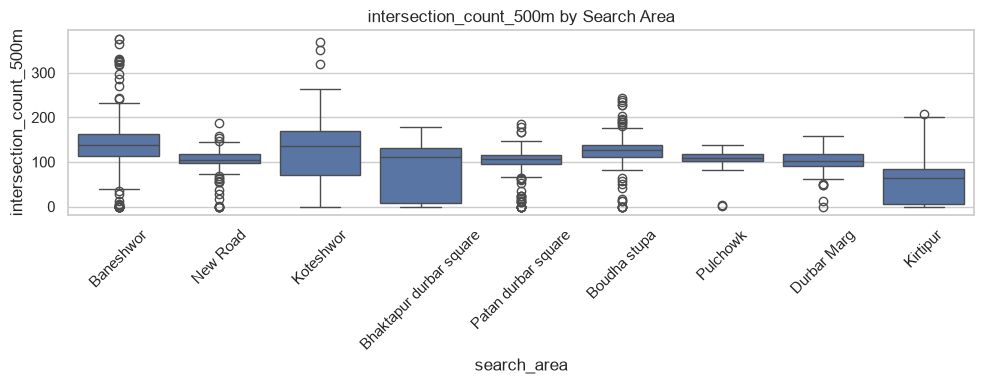

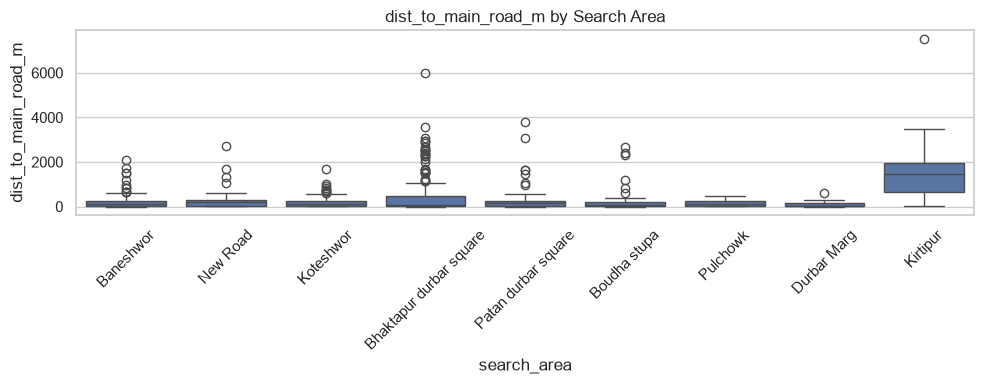

In [41]:
# Load raw accessibility feature dataset
df = pd.read_csv("../data/processed/sub_groups/accessibility_features.csv")

# Relevant columns for accessibility feature EDA
feature_cols = ["bus_stop_count_500m", "parking_space_count_500m", "intersection_count_500m", "dist_to_main_road_m"]

# Preview data
print(df[["search_area"] + feature_cols].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[["search_area"] + feature_cols].isnull().sum())

# Summary statistics
summary = df[feature_cols].describe().T
summary

# Histograms for each feature
plt.figure(figsize=(14, 6))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[feature_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Accessibility Features')
plt.show()

# Compare accessibility by search area
for col in feature_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='search_area', y=col)
    plt.title(f'{col} by Search Area')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Accessibility factor EDA
This section analyzes the aggregated accessibility score from the accessibility factor file.

  search_area  Accessibility
0   Baneshwor         0.4165
1   Baneshwor         0.4903
2   Baneshwor         0.5682
3   Baneshwor         0.5350
4   Baneshwor         0.5848
Dataset shape: (1472, 6)
Missing values:
 search_area      0
Accessibility    0
dtype: int64
count    1472.000000
mean        0.419404
std         0.116756
min         0.000000
25%         0.354100
50%         0.414600
75%         0.495250
max         0.752200
Name: Accessibility, dtype: float64


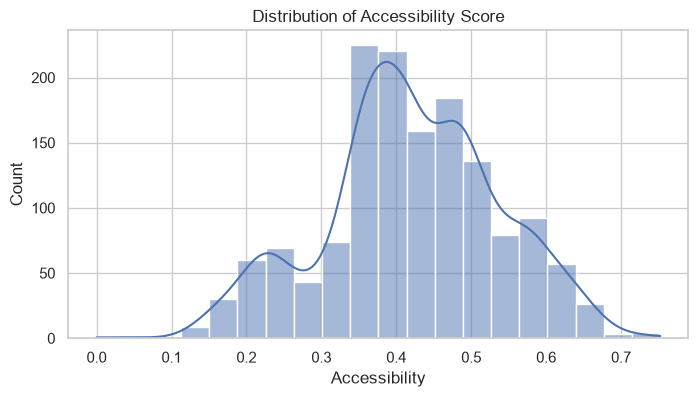

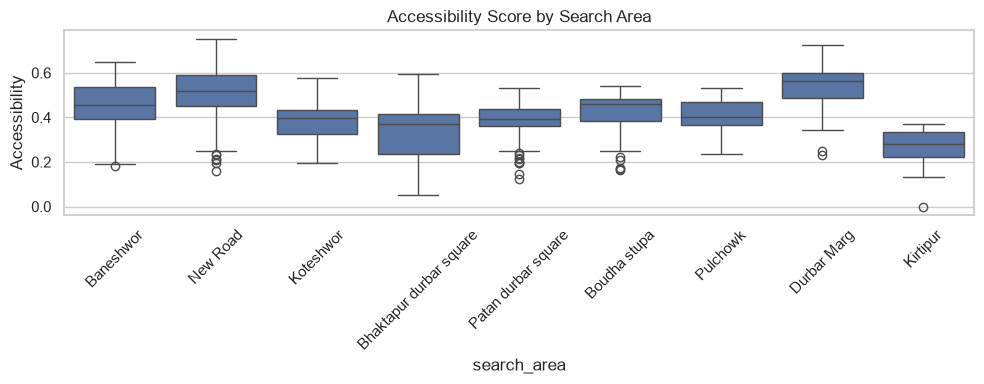

In [42]:
# Load aggregated accessibility score dataset
df = pd.read_csv("../data/processed/sub_groups/accessibility_factor.csv")

# Preview data
print(df[['search_area', 'Accessibility']].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[['search_area', 'Accessibility']].isnull().sum())

# Summary statistics
print(df['Accessibility'].describe())

# Distribution of accessibility score
plt.figure(figsize=(8, 4))
sns.histplot(df['Accessibility'], kde=True, bins=20)
plt.title('Distribution of Accessibility Score')
plt.show()

# Compare accessibility score by search area
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='search_area', y='Accessibility')
plt.title('Accessibility Score by Search Area')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Final dataset EDA
This section analyzes the merged dataset directly. Since Competition is already included in the final CSV, the EDA focuses on the combined features: Demand, Accessibility, Competition, Population, and the target label.

In [44]:
# Load final merged dataset
df = pd.read_csv("../data/processed/dataset_final.csv")

# Feature columns for analysis
feature_cols = ["Demand", "Accessibility", "Competition", "Population"]
target_col = "label"

# Preview data
print(df[["search_area"] + feature_cols + [target_col]].head())

# Check shape and missing values
print("Dataset shape:", df.shape)
print("Missing values:\n", df[["search_area"] + feature_cols + [target_col]].isnull().sum())


  search_area  Demand  Accessibility  Competition  Population  label
0   Baneshwor  0.2995         0.4165       0.4850      0.4712      1
1   Baneshwor  0.4008         0.4903       0.4213      0.4351      1
2   Baneshwor  0.4458         0.5682       0.4101      0.4219      1
3   Baneshwor  0.2319         0.5350       0.4891      0.5552      1
4   Baneshwor  0.4351         0.5848       0.4088      0.4260      1
Dataset shape: (4172, 9)
Missing values:
 search_area      0
Demand           0
Accessibility    0
Competition      0
Population       0
label            0
dtype: int64


In [45]:
# Summary statistics for the final features and target
summary = df[feature_cols + [target_col]].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
Demand,4172.0,0.236463,0.143550,0.0000,0.126075,0.22615,0.329325,0.6593
Accessibility,4172.0,0.396715,0.113498,0.0000,0.333725,0.39595,0.469125,0.7574
Competition,4172.0,0.482614,0.108753,0.2091,0.426575,0.49160,0.525300,1.0000
Population,4172.0,0.364638,0.200844,0.0000,0.242200,0.35200,0.475650,1.0000
label,4172.0,0.352828,0.477907,0.0000,0.000000,0.00000,1.000000,1.0000


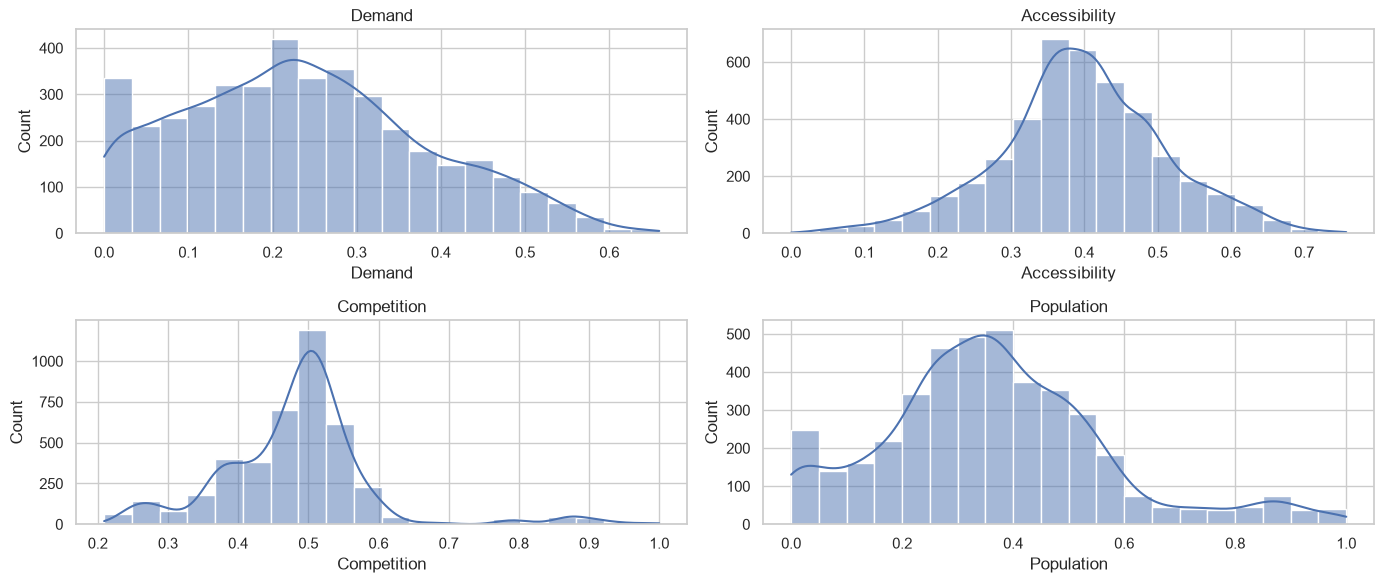

In [46]:
# Distribution of each feature
plt.figure(figsize=(14, 6))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()


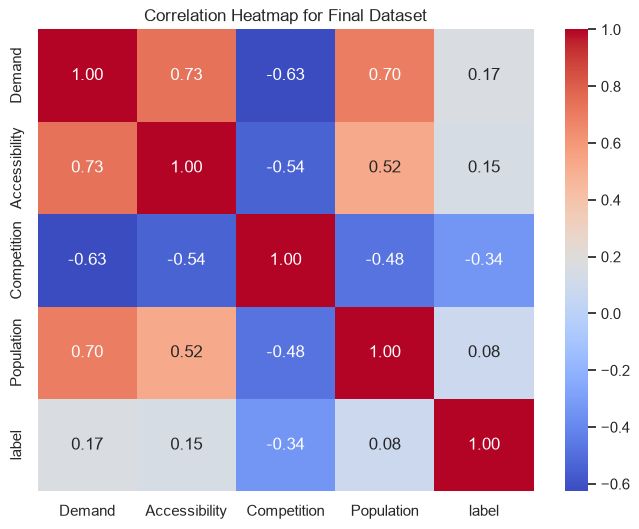

In [ ]:
# Correlation heatmap for final dataset
corr = df[feature_cols + [target_col]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Final Dataset')
plt.show()


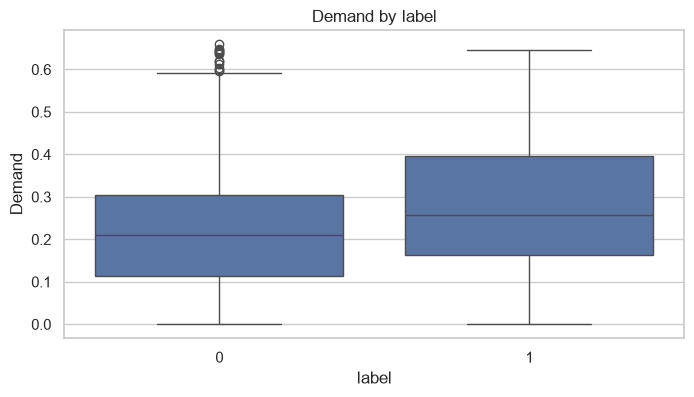

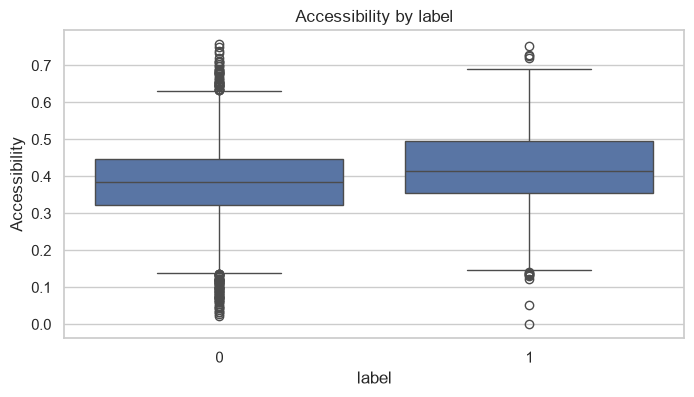

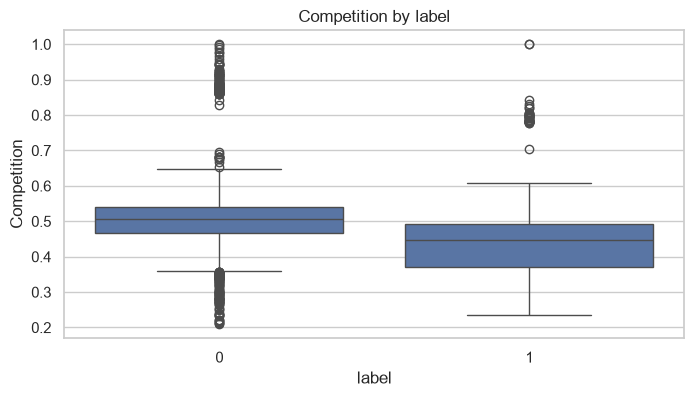

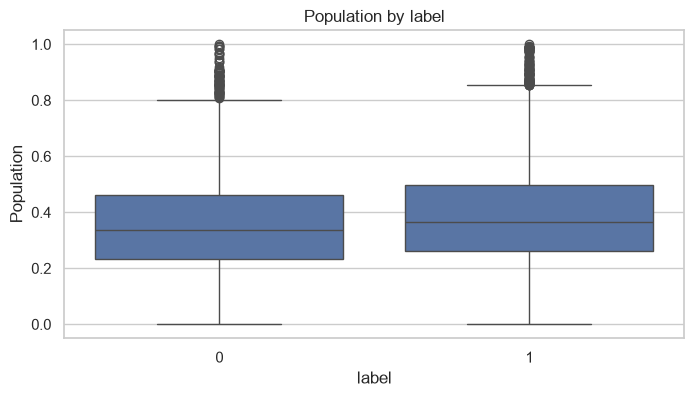

In [48]:
# Feature vs target comparison by label
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f'{col} by {target_col}')
    plt.show()
